# Regression Discontinuity Designs

Regression Discontinuity Designs (RDDs) are used to estimate the Local Average
Treatment Effect in natural experiments that involve a continuous variable that
*suddenly* show some kind of discontinuous behavior. Examples include students
who are granted a scholarship based on their SAT scores, or policies that get
rolled out at a given timestamp.

The core idea is that observations right around the discontinuity are very
similar to each other, with the only exception being that some observations
are on the left side of the cutoff, while the rest are on the right.

To express this idea mathematically, let $X$ be some continuous random variable
(e.g., time) $X = c$ be the discontinuity (e.g., the exact moment in time a
given policy goes live). Then, the treatment effect at the cutoff, $\tau$, is:

$$\tau = \lim_{x \leftarrow c} E[Y|X=x] - \lim_{x \rightarrow c} E[Y|X=x]$$

---

Imports

In [1]:
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
import statsmodels.api as sm

## Key Components

* Running Variable ($X$): A continuous variable used to determine treatment
eligibility.

* Cutoff ($c$): The specific value of the running variable that determines the
discontinuous jump in treatment eligibility.

* The *Centered* Running Variable ($R = X - c$): This is just a transformation
of the original running variable that makes the math cleaner.

* Treatment ($D$): The intervention to be studied.

* Outcome ($Y$): The dependent variable.

## Key Assumptions

* Units cannot choose which side of the discontinuity they're on. In other
words, data points can't choose *when* they get treated (if $X$ is time) or
manipulate their scores (if $X$ represents SAT scores). Mathematically, this
means that observations cannot tamper with their value of $X$.

* There must be no other interventions at the exact same cutoff. Otherwise, we
cannot distinguish which one caused the effect.

* The data points are evenly distributed along the running variable. That is,
there isn't an unusually high density of observations just below or above the
cutoff.


## Sharp RDD

In this design, the treatment status is deterministic.

* $D = 0 if X \lt c$
* $D = 1 if X \ge c$

As we'll see, this is not always the case. For example, there may be students
who have a high enough SAT score to get a scholarship but choose not to take it
(i.e., $x_i \gt c$, but $D_i = 0$). We will talk more about this design later on
in this lecture.

### Basic Form

In its most basic form, the specification is:

$$Y_i = \beta_0 + \beta_1 D_i + \beta_2 R_i + \varepsilon_i$$

We can make this model more flexible by:

* Allowing the *slope* to change after the intervention.
* Allowing for polynomial effects in the running variable (though this will
tend to overfit the data).
* Allowing some kind of non-linear function $f(R)$, such as a spline, kernel
regression, etc.

### Lee (2008)

To illustrate Sharp RDDs, we will use the data from Lee (2008). This article
studies the effect of being the incumbent (i.e., the politician who's currently
holding a given position) on winning the next election.

The core hypothesis is that politicians who win with a very small margin (i.e.,
the share of votes is slightly above the 50% mark) are practically identical
to the runner ups. Hence, the author uses the margin of victory as the running
variable and measures if there's a statistically significant discontinuity
at the 0% mark.

The base model is:

$$Y_{i1} = \beta_0 + \beta_1 Y_{i0} + f(R_i) + \varepsilon$$

Where $t = 0$ represents the current election, $t = 1$ represents the next
election, Y_{it} is a binary variable that shows if candidate $i$ won the
election at time $t$, $f$ is some function of $R$, and $R$ is the margin of
victory measured in percentage points.

---

Read Data

In [2]:
# Load data
PATH = os.path.join('data', 'lee.csv')
df = pd.read_csv(PATH)

# Assign constant
df['const'] = 1

Let's visualize the running variable's distribution (margins of victory). This
bit is important because the whole assumption of quasi-randomness around the
cutoff would be invalidated if units (politicians) could choose or alter their
own value for the running variable.

To test whether the density of observations is continuous at the threshold, we
can run a [McCrary Density Test](
    https://www.sciencedirect.com/science/article/abs/pii/S0304407607001133
). However, judging by the histogram below, there doesn't seem to be an unusual
bunching of observations just above or below the cutoff.

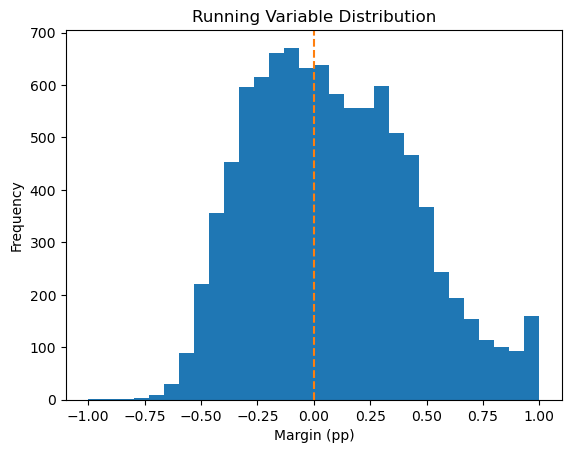

In [3]:
plt.hist(df['margin'], bins=30)
plt.axvline(x=0, color='C1', ls='--')
plt.title('Running Variable Distribution')
plt.xlabel('Margin (pp)')
plt.ylabel('Frequency')
plt.show()

The response variable is a binary column (win/lose) that we will be modeling
with linear probability models. Plotting the data points as simple 1s and 0s
is not very pleasing.

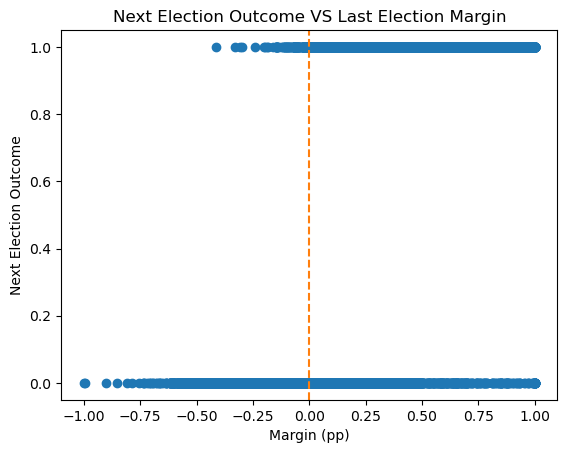

In [4]:
plt.scatter(
    x=df['margin'],
    y=df['win_1']
)
plt.axvline(x=0, color='C1', ls='--')
plt.title('Next Election Outcome VS Last Election Margin')
plt.xlabel('Margin (pp)')
plt.ylabel('Next Election Outcome')
plt.show()

Visualizing the data correctly is key in RDDs! The idea is so simple that having
aesthetically pleasing plots is super important for this type of designs.

In the paper, the author bins column `'margin'` and calculates the average
win probability next election. This transformation **IS NOT** used in the
regression models though. It's only used for visualization purposes.

In [5]:
# Declare the limits of each bin
x_ticks = np.arange(start=-1.0, stop=1.1, step=0.1)

# Cut column `margin` into bins using `pd.cut`
df['bin'] = pd.cut(x=df['margin'], bins=x_ticks)

/var/folders/k3/s4tf_ms52ps14k4cfz0cj7s00000gn/T/ipykernel_62945/14951218.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_means = df.groupby('bin')['win_1'].mean()


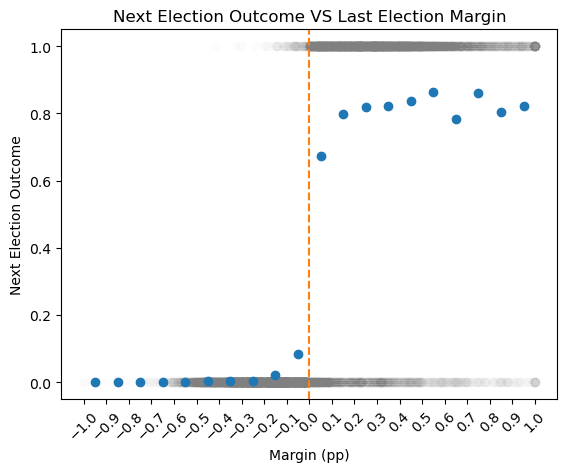

In [6]:
# Declare the limits of each bin
x_ticks = np.linspace(start=-1.0, stop=1, num=21)

# Cut column `margin` into bins using `pd.cut`
df['bin'] = pd.cut(x=df['margin'], bins=x_ticks)

# Get average win rate of next election per bin
grouped_means = df.groupby('bin')['win_1'].mean()

# Plot bins
plt.scatter(df['margin'], df['win_1'], color='gray', alpha=0.01)
plt.scatter(
    x=x_ticks[:-1] + 0.05,  # Centering each value in the middle of each bin
    y=grouped_means.values
)
plt.axvline(x=0, color='C1', ls='--')
plt.xticks(ticks=x_ticks, rotation=45)
plt.title('Next Election Outcome VS Last Election Margin')
plt.xlabel('Margin (pp)')
plt.ylabel('Next Election Outcome')
plt.show()

#### Linear Models

Let's run a linear model with a single slope for bot sides.

In [7]:
# Declare model
m0 = sm.OLS(
    endog=df['win_1'],
    exog=df[['const', 'win_0', 'margin']],
    hasconst=True
)

# Fit model
r0 = m0.fit(cov_type='HC1')

# View results
print(r0.summary())

                            OLS Regression Results                            
Dep. Variable:                  win_1   R-squared:                       0.597
Model:                            OLS   Adj. R-squared:                  0.596
Method:                 Least Squares   F-statistic:                     8815.
Date:                Sat, 09 May 2026   Prob (F-statistic):               0.00
Time:                        09:30:10   Log-Likelihood:                -2581.1
No. Observations:                9674   AIC:                             5168.
Df Residuals:                    9671   BIC:                             5190.
Df Model:                           2                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0627      0.005     11.777      0.0

Let's run another linear model with heterogeneous margin effects on both sides
of the discontinuity.

In [8]:
# Declare interaction term
df['margin_win_0'] = df['margin'].multiply(df['win_0'])

# Declare model
m1 = sm.OLS(
    endog=df['win_1'],
    exog=df[['const', 'win_0', 'margin', 'margin_win_0']],
    hasconst=True
)

# Fit model
r1 = m1.fit(cov_type='HC1')

# View results
print(r1.summary())

                            OLS Regression Results                            
Dep. Variable:                  win_1   R-squared:                       0.597
Model:                            OLS   Adj. R-squared:                  0.596
Method:                 Least Squares   F-statistic:                     6804.
Date:                Sat, 09 May 2026   Prob (F-statistic):               0.00
Time:                        09:30:10   Log-Likelihood:                -2580.9
No. Observations:                9674   AIC:                             5170.
Df Residuals:                    9670   BIC:                             5198.
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0670      0.006     10.413   

#### Polynomial Models

Let's now run a model with quadratic heterogeneous effects.

In [9]:
# Declare quadratic terms
df['margin_sq'] = df['margin'].pow(2)
df['margin_sq_win_0'] = df['margin_sq'].multiply(df['win_0'])

# Declare model
m2 = sm.OLS(
    endog=df['win_1'],
    exog=df[[
        'const', 'margin', 'margin_sq',
        'win_0', 'margin_win_0', 'margin_sq_win_0'
    ]],
    hasconst=True
)

# Fit model
r2 = m2.fit(cov_type='HC1')

# View results
print(r2.summary())

                            OLS Regression Results                            
Dep. Variable:                  win_1   R-squared:                       0.601
Model:                            OLS   Adj. R-squared:                  0.601
Method:                 Least Squares   F-statistic:                     4226.
Date:                Sat, 09 May 2026   Prob (F-statistic):               0.00
Time:                        09:30:10   Log-Likelihood:                -2528.3
No. Observations:                9674   AIC:                             5069.
Df Residuals:                    9668   BIC:                             5112.
Df Model:                           5                                         
Covariance Type:                  HC1                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.1006      0.010     

#### Ultimate plot

Plot results from `r0`

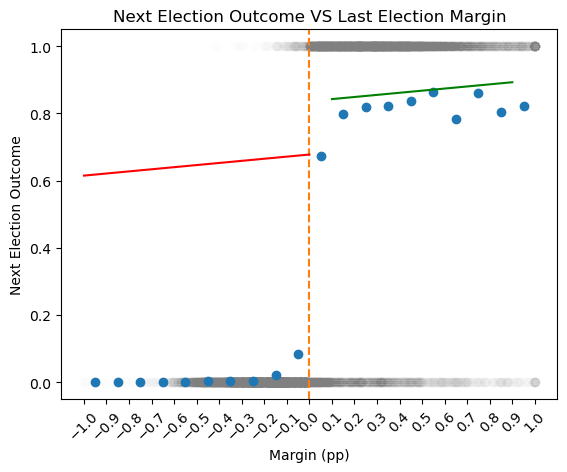

In [10]:
# Generate data to feed to the model (in same format as it was trained)
pred = pd.DataFrame(data={'margin': x_ticks[:-1]})
pred['const'] = 1
pred['win_0'] = pred['margin'].gt(0.0).astype(int)
pred['y_hat'] = r0.predict(pred)

# Old plot
plt.scatter(df['margin'], df['win_1'], color='gray', alpha=0.01)
plt.scatter(
    x=x_ticks[:-1] + 0.05,  # Centering each value in the middle of each bin
    y=grouped_means.values
)
plt.axvline(x=0, color='C1', ls='--')
# Add new predicted values
plt.plot(
    pred.loc[pred['margin'].le(0), 'margin'],
    pred.loc[pred['margin'].le(0), 'y_hat'],
    color='red'
)
plt.plot(
    pred.loc[pred['margin'].gt(0), 'margin'],
    pred.loc[pred['margin'].gt(0), 'y_hat'],
    color='green'
)
# Aesthetics
plt.xticks(ticks=x_ticks, rotation=45)
plt.title('Next Election Outcome VS Last Election Margin')
plt.xlabel('Margin (pp)')
plt.ylabel('Next Election Outcome')
plt.show()

## Fuzzy RDD

In this design, the treatment status is probabilistic rather than deterministic.
The probability of receiving treatment jumps at the cutoff, but it does not
change from 0 to 1 perfectly.

$$P(D = 1 | X \ge c) \gt P(D = 1 | X \lt c)$$

Following the previous example, there may be students who score just below the
SAT cutoff but still receive a scholarship due to appeals or special
circumstances (i.e., $X_i \lt c$, but $D_i = 1$). Likewise, some who qualify
might decline it. The cutoff acts as an instrument for treatment rather than a
strict rule.

### Basic Form

Because treatment assignment is endogenous, Fuzzy RDDs are typically estimated
the 2SLS method we used in IVs, treating the threshold crossing as an
instrumental variable ($Z_i$).

* Let $Z_i = 1$ if $X_i \ge c$ and $0$ otherwise.

**First Stage:**
We predict actual treatment ($D_i$) using the threshold instrument ($Z_i$) and
the centered running variable ($R_i$):

$$D_i = \gamma_0 + \gamma_1 Z_i + \gamma_2 R_i + u_i$$

**Second Stage:**
We estimate the effect on the outcome ($Y_i$) using the predicted treatment
($\hat{D}_i$):

$$Y_i = \beta_0 + \beta_1 \hat{D}_i + \beta_2 R_i + \varepsilon_i$$

Important considerations for this model:

* It estimates a Local Average Treatment Effect (LATE), meaning the effect is
only valid for "compliers"—those whose treatment status was dictated by the
cutoff.
* Similar to Sharp RDD, you can allow the slope of the running variable to
change at the cutoff or use non-parametric methods.
* The instrument ($Z_i$) must satisfy the relevance and exclusion restrictions.